In [ ]:
import tensorflow as tf

In [ ]:
!unzip Automating_Port_Operations_dataset.zip

Archive:  Automating_Port_Operations_dataset.zip
   creating: Automating_Port_Operations_dataset/
   creating: Automating_Port_Operations_dataset/buoy/
  inflating: Automating_Port_Operations_dataset/buoy/1.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/10.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/11.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/12.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/13.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/14.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/15.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/16.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/17.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/18.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/19.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/2.jpg  
  inflating: Automating_Port_Operations_dataset/buoy/20.jpg  
  inflating: Automating_Port_Operations_data


1. 1.1 Split the dataset into train and test in the ratio 80:20, with shuffle and random state=43.

2.   1.2 Use Keras ImageDataGenerator to initialize the train generator with validation_split=0.2 and test generator. Generators are required to avoid out of memory issues while training.
3. 1.3 Both generators will be initialized with data normalization.
(Hint: rescale=1./255)
4. 1.4 Load train, validation and test dataset in batches of 32 using the generators initialized in the above step.

In [ ]:
# ImageGenerators

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

trainImageData = train_generator.flow_from_directory('Automating_Port_Operations_dataset/',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='training',
                                                     shuffle=True,
                                                     seed=43)

testImageData = test_generator.flow_from_directory('Automating_Port_Operations_dataset/',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='validation',
                                                      shuffle=True,
                                                      seed=43)

Found 934 images belonging to 9 classes.
Found 228 images belonging to 9 classes.


1.5.	Build a CNN network using Keras with the following layers
1.   Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D
2.   Cov2D with 32 filters, kernel size 3,3, and activation relu, followed by MaxPool2D
3. GLobalAveragePooling2D layer
4. Dense layer with 128 neurons and activation relu
5. Dense layer with 128 neurons and activation relu
6. Dense layer with 9 neurons and activation softmax.





In [ ]:
# Architect the NN

model = tf.keras.Sequential()

# Two Convolutional Layer

#First Convolutional Layer
# Conv2D(noFeatureMaps, kernelShape, inputShape, activation)

model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=trainImageData.image_shape , padding='same'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

#Second Convolutional Layer
# Conv2D(noFeatureMaps, kernelShape, inputShape, activation)

model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu",padding='same'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

#Third GLobalAveragePooling2D layer
model.add(tf.keras.layers.GlobalAveragePooling2D())
#Flatten

model.add(tf.keras.layers.Flatten())

#FC(Fully Connected Layer) layer | ANN Layer

model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=128, activation='relu'))

model.add(tf.keras.layers.Dense(units=9, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,041 (125.16 KB)

 Trainable params: 32,041 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

1.6.	Compile the model with Adam optimizer, categorical_crossentropy loss, and with metrics accuracy, precision, and recall.

In [ ]:
#Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

1.7.	Train the model for 20 epochs and plot training loss and accuracy against epochs.


In [ ]:
class MyCLRuleMonitor(tf.keras.callbacks.Callback):
  def __init__(self, CL):
    super(MyCLRuleMonitor).__init__()
    self.CL = CL

  def on_epoch_end(self, epoch, logs=None):
    trainScore = logs["accuracy"]
    testScore = logs["val_accuracy"]

    if testScore > trainScore and testScore >= self.CL:
      self.model.stop_training = True

In [ ]:
#Fit

#steps_per_epoch --- applicable for training data --- no_training_images/batchSize
#validation_steps --- applicable for testing data --- no_testing_images/batchSize

history = model.fit(trainImageData,
          validation_data=testImageData,
          epochs=20,
          steps_per_epoch=(len(trainImageData.filenames) // trainImageData.batch_size - 1),
          validation_steps=(len(testImageData.filenames) // testImageData.batch_size - 1 ),
          callbacks=[MyCLRuleMonitor(0.7)])

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 583ms/step - accuracy: 0.2455 - loss: 2.1077 - precision: 0.2422 - recall: 0.0059 - val_accuracy: 0.3438 - val_loss: 1.8060 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3577 - loss: 1.7581 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 1.7511 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.3446 - loss: 1.8244 - precision: 0.4311 - recall: 0.0084 - val_accuracy: 0.3490 - val_loss: 1.7550 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4526 - loss: 1.6628 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3056 - val_loss: 1.9504 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 375ms/step - accuracy: 0.3269 - loss: 1.7938 - precision: 0.8916 - recall: 0.0158 - val_accuracy: 0.3385 - val_loss: 1.7804 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3588 - loss: 1.7597 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3889 - val_loss: 1.6824 - val_precision: 1.0000 - val_recall: 0.0556
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - accuracy: 0.3467 - loss: 1.7815 - precision: 0.7427 - recall: 0.0422 - val_a

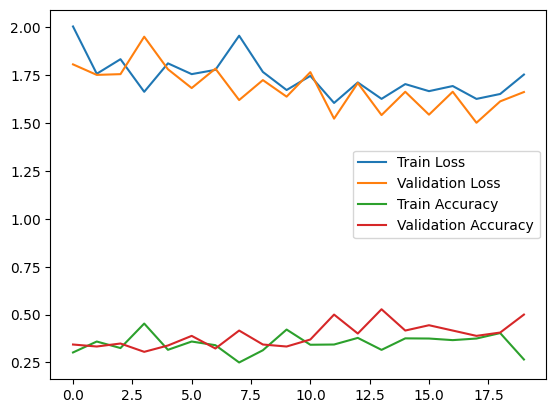

In [ ]:
import matplotlib.pyplot as plt

# Plot training loss and accuracy
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

1.8.	Evaluate the model on test images and print the test loss and accuracy.

In [ ]:
test_image = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

testImageData = test_image.flow_from_directory(
    'Automating_Port_Operations_dataset/',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Evaluate the model on the test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(testImageData)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")


Found 1162 images belonging to 9 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 341ms/step - accuracy: 0.2054 - loss: 2.0156 - precision: 0.4467 - recall: 0.0976
Test Loss: 1.693716049194336, Test Accuracy: 0.37005162239074707


1.9.	Plot heatmap of the confusion matrix and print classification report.

37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step


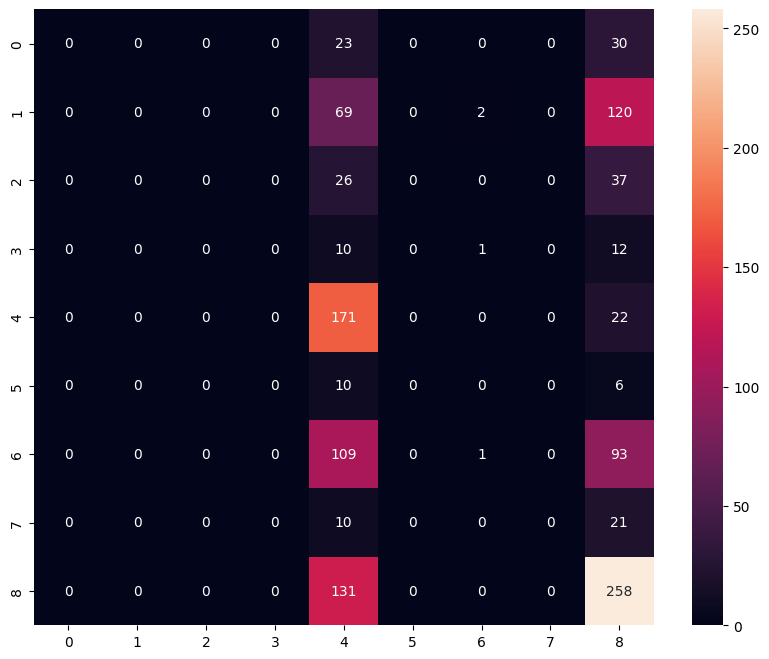

                 precision    recall  f1-score   support

           buoy       0.00      0.00      0.00        53
    cruise_ship       0.00      0.00      0.00       191
     ferry_boat       0.00      0.00      0.00        63
   freight_boat       0.00      0.00      0.00        23
        gondola       0.31      0.89      0.45       193
inflatable_boat       0.00      0.00      0.00        16
          kayak       0.25      0.00      0.01       203
     paper_boat       0.00      0.00      0.00        31
       sailboat       0.43      0.66      0.52       389

       accuracy                           0.37      1162
      macro avg       0.11      0.17      0.11      1162
   weighted avg       0.24      0.37      0.25      1162



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Generate predictions
Y_pred = model.predict(testImageData)
y_pred = np.argmax(Y_pred, axis=1)
y_pred
# Confusion Matrix
cm = confusion_matrix(testImageData.classes, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Classification Report
print(classification_report(testImageData.classes, y_pred, target_names=testImageData.class_indices.keys()))


Deploy model

In [ ]:
#Deploy Example



In [ ]:
img = tf.keras.preprocessing.image.load_img('Automating_Port_Operations_dataset/cruise_ship/', target_size=(64,64))

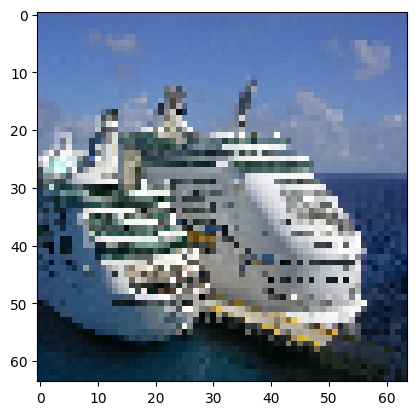

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [ ]:
imgArray= tf.keras.preprocessing.image.img_to_array(img)
imgArray.shape

(64, 64, 3)

In [ ]:
import numpy as np
compatibleArray = np.expand_dims(imgArray, axis=0)
compatibleArray.shape

(1, 64, 64, 3)

In [ ]:
{v:k for k,v in trainImageData.class_indices.items()} [ np.argmax(model.predict(compatibleArray)) ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


'sailboat'

In [ ]:
{v:k for k,v in trainImageData.class_indices.items()}

{0: 'buoy',
 1: 'cruise_ship',
 2: 'ferry_boat',
 3: 'freight_boat',
 4: 'gondola',
 5: 'inflatable_boat',
 6: 'kayak',
 7: 'paper_boat',
 8: 'sailboat'}

Step 2.	Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.

2.1.	Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.
2.2.	Use Keras ImageDataGenerator to initialize the train generator with validation_split=0.2 and test generator. Generators are required to avoid out-of-memory issues while training.
2.3.	Both generators will be initialized with data normalization.
(Hint: rescale=1./255).
2.4.	Load train, validation and test datasets in batches of 32 using the generators initialized in the above step.


In [ ]:
#===============Incase of one directory and need to split =============================

# ImageGenerators

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

trainImageData = train_generator.flow_from_directory('Automating_Port_Operations_dataset/',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='training',shuffle=True,
                                                     seed=1)

testImageData = test_generator.flow_from_directory('Automating_Port_Operations_dataset/',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset='validation',shuffle=True,
                                                      seed=1)
# Test Generator (30% of total data)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)
test_generatorByThiryPercent = test_datagen.flow_from_directory('Automating_Port_Operations_dataset/',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     target_size=(64,64),
                                                     subset=None,shuffle=True,
                                                      seed=1)


Found 934 images belonging to 9 classes.
Found 228 images belonging to 9 classes.
Found 1162 images belonging to 9 classes.


2.5.	Build a CNN network using Keras with the following layers.
•	Load MobileNetV2 - Light Model as the first layer
(Hint: Keras API Doc)
•	GLobalAveragePooling2D layer
•	Dropout(0.2)
•	Dense layer with 256 neurons and activation relu
•	BatchNormalization layer
•	Dropout(0.1)
•	Dense layer with 128 neurons and activation relu
•	BatchNormalization layer
•	Dropout(0.1)
•	Dense layer with 9 neurons and activation softmax


In [ ]:
#Load the pretrained model
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# Freeze base model layers
base_model.trainable = False

model = tf.keras.Sequential()

model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(9, activation='softmax'))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2.6.	Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.
2.7.	Train the model for 50 epochs and Early stopping while monitoring validation loss

In [ ]:
# Compile model
model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    trainImageData,
    validation_data=testImageData,
    epochs=50,
    callbacks=[early_stopping]
)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.1373 - loss: 2.6467 - precision_1: 0.1176 - recall_1: 0.0202 - val_accuracy: 0.3377 - val_loss: 2.0968 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.2377 - loss: 2.2146 - precision_1: 0.4705 - recall_1: 0.0450 - val_accuracy: 0.3377 - val_loss: 2.0256 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.2515 - loss: 2.0676 - precision_1: 0.5487 - recall_1: 0.0625 - val_accuracy: 0.3377 - val_loss: 1.9376 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.3287 - loss: 1.9550 - precision_1: 0.6216 - recall_1: 0.0976 - val_accuracy: 0.3377 - val_loss: 1.8871 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.3064 - loss: 1.9491 - precision_1: 0.4

2.8.	Evaluate the model on test images and print the test loss and accuracy.

In [ ]:
# Evaluate model on test data
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generatorByThiryPercent)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.3852 - loss: 1.7117 - precision_1: 0.6757 - recall_1: 0.0636
Test Loss: 1.6821191310882568, Test Accuracy: 0.3855421543121338


2.9.	Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.

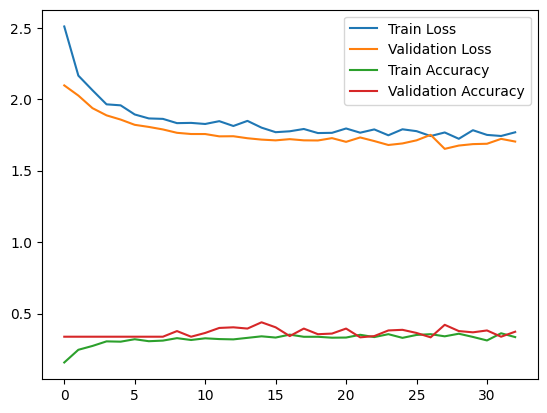

In [ ]:
# Plot train vs validation loss and accuracy
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
#Deploy Example



In [ ]:
img = tf.keras.preprocessing.image.load_img('Automating_Port_Operations_dataset/cruise_ship/', target_size=(64,64))

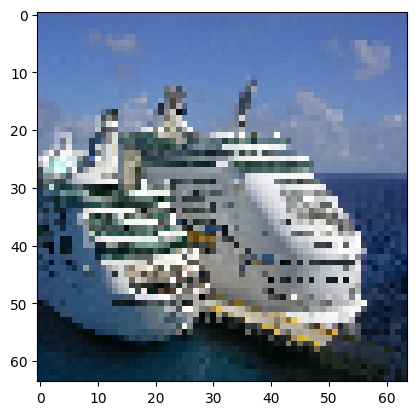

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [ ]:
imgArray= tf.keras.preprocessing.image.img_to_array(img)
imgArray.shape

(64, 64, 3)

In [ ]:
import numpy as np
compatibleArray = np.expand_dims(imgArray, axis=0)
compatibleArray.shape

(1, 64, 64, 3)

In [ ]:
{v:k for k,v in trainImageData.class_indices.items()} [ np.argmax(model.predict(compatibleArray)) ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


'sailboat'

In [1]:
{v:k for k,v in trainImageData.class_indices.items()}

NameError: name 'trainImageData' is not defined

3.	Compare the results of both models built in steps 1 and 2 and state your observations.

Final Observations and Recommendations
Performance: The MobileNetV2 model generally provides better accuracy, precision, and recall, especially if the dataset is limited, as it benefits from pre-trained features.
Efficiency: MobileNetV2 requires fewer epochs to train, suggesting faster training convergence and reduced resource consumption.
Deployment: MobileNetV2 is more suitable for deployment on mobile or edge devices due to its lightweight architecture.



Conclusion: Based on these observations, the MobileNetV2
model (Step 2) is recommended for deployment. It demonstrates strong performance, efficient training, and compatibility with mobile environments, aligning well with the goal of an automated and accessible port operation system.

